In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.units import u
from astropy.coordinates import SkyCoord
import sys
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval

pf.housestyle_rcparams()

True

In [ ]:
CUBE_PATH = '../../cubes/macs0159m34_COMBINED_CUBE_MED_FINAL.fits'
# CUBE_PATH = '../../cubes/s780_COMBINED_CUBE_MED_FINAL.fits'
TITLE = 'MACS'
RADIUS_ARCSEC = .6
Z = 0.249

ra_hms = '01h59m04.03s'
dec_dms = '-34d13m31.8s'
coords = SkyCoord(ra_hms, dec_dms, frame='icrs')
RA_DEG = coords.ra.deg
DEC_DEG = coords.dec.deg

In [45]:
def generate_gaussian_profile(params, num_points=500, width_factor=4.0):
    sigma = params.fwhm / (2 * np.sqrt(2 * np.log(2)))
    x_min = params.lpeak - width_factor * params.fwhm / 2
    x_max = params.lpeak + width_factor * params.fwhm / 2
    x = np.linspace(x_min, x_max, num_points)
    y = params.cont + params.peak * np.exp(-((x - params.lpeak) ** 2) / (2 * sigma ** 2))
    return np.vstack((x, y))

def load_cube(path):
    print(f'Loading datacube: {path}...')
    try:
        cube = Cube(path)
        print(f'Successfully loaded cube. Dimensions: {cube.shape}')
        return cube
    except FileNotFoundError:
        print(f'Error: Datacube not found at {path}')
        sys.exit(1)

def extract_spectrum(cube, ra, dec, radius):
    center = (dec, ra)
    print(f'\nExtracting spectrum at (RA, Dec) = ({ra:.6f}, {dec:.6f}) with a {radius}" radius aperture.')
    spec = cube.aperture(center, radius, is_sum=True)
    print('Extraction complete.')
    return spec

def plot_spectrum_and_cutout(spec, cube, ra, dec, radius, title, pref):
    fig, ax = pf.create_plot(size=(8, 2))
    ax_cont = fig.add_axes((1.02, 0, 1/4, 1))
    spec.plot(ax=ax, title=f'{title} at (RA={ra:.4f}, Dec={dec:.4f})', color='#ff004f')
    ax.set_xlabel(r'Wavelength, $\lambda$, [$\AA$]')
    ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')
    fig.canvas.manager.set_window_title('Extracted Spectrum')

    subcube_cont = cube.select_lambda(7000, 7500)
    im_cont = subcube_cont.mean(axis=0)
    im_cutout = im_cont.subimage(center=(dec, ra), size=4.0)

    vmin, vmax = ZScaleInterval().get_limits(im_cutout.data)
    im_cutout.plot(ax=ax_cont, vmin=vmin, vmax=vmax, show_xlabel=False, show_ylabel=False, cmap='magma')
    ax_cont.set_xticks([])
    ax_cont.set_yticks([])

    center_pix_yx = im_cutout.wcs.sky2pix([dec, ra], 1)[0]
    # radius_pix = radius / im_cutout.wcs.get_step()[0] #broken
    aperture_circle = Circle((center_pix_yx[1], center_pix_yx[0]), 3, edgecolor='white', facecolor='none', lw=2, zorder=10)
    ax_cont.add_patch(aperture_circle)

    pf.fix_plot([ax])
    fig.savefig(f'figs/{title}_{pref}_spectra.png', dpi=600, bbox_inches='tight')

def measure_redshift(spec, z_guess):
    print('\nMeasuring spectroscopic redshift...')
    lines_for_z = {'Hbeta': 4861.33, 'OIII_5007': 5006.84, 'Halpha': 6562.80}
    redshifts = []
    for name, rest_wave in lines_for_z.items():
        obs_wave_guess = rest_wave * (1 + z_guess)
        try:
            fit = spec.gauss_fit(lmin=(obs_wave_guess - 30), lmax=(obs_wave_guess + 30), plot=False)
            line_z = (fit.lpeak / rest_wave) - 1
            redshifts.append(line_z)
            print(f'  - {name}: Found at {fit.lpeak:.2f} \AA, z = {line_z:.5f}')
        except Exception:
            print(f'  - {name}: Fit failed near {obs_wave_guess:.2f} \AA.')

    if not redshifts:
        print('\nError: Could not measure redshift. Using initial guess.')
        return z_guess, 0.0
    
    z_measured = np.mean(redshifts)
    z_err = np.std(redshifts) / np.sqrt(len(redshifts)) if len(redshifts) > 1 else 0.0
    print(f'\nMeasured Redshift z = {z_measured:.5f} \xB1 {z_err:.5f}')
    return z_measured, z_err

def deredshift_spectrum(spec, z):
    spec_rest = spec.copy()
    spec_rest.wave.set_crval(spec_rest.wave.get_crval() / (1 + z))
    spec_rest.wave.set_step(spec_rest.wave.get_step() / (1 + z))
    return spec_rest

def fit_emission_lines(spec_rest):
    lines = {'Hbeta': 4861.33, 'OIII_5007': 5006.84, 'Halpha': 6562.80, 'NII_6583': 6583.45}
    line_fits = {}
    for name, wave in lines.items():
        try:
            line_fits[name] = spec_rest.gauss_fit(lmin=(wave - 15), lmax=(wave + 15), plot=False)
        except Exception:
            line_fits[name] = None
    return line_fits

def plot_line_fits(spec_rest, line_fits, z, z_err, title, pref):
    titles = {'Hbeta': r'H$\beta$', 'OIII_5007': r'O$_{\mathrm{III-}5007}$', 'Halpha': r'H$\alpha$', 'NII_6583': r'N$_{\mathrm{II-}6583}$'}
    fig, axes = plt.subplots(2, 2, figsize=(8, 7.5))
    fig.canvas.manager.set_window_title('Emission Line Fits')

    for ax, name in zip(axes.ravel(), titles.keys()):
        fit = line_fits.get(name)
        if fit:
            profile = generate_gaussian_profile(fit, 500, 100)
            ax.plot(profile[0], profile[1], color='k', lw=1.4)
            spec_rest.plot(ax=ax, color='#ff004f')
            ax.set_xlim([np.min(profile[0]), np.max(profile[0])])
            ax.set_title(titles[name])
            ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')
            ax.set_xlabel(r'Rest Frame $\lambda$, [$\AA$]')
        else:
            ax.set_title(f'{titles[name]} (Fit Failed)')
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    
    title_lines = [fr'$z = {z:.5f} \pm {z_err:.5f}$' if z_err > 0 else f'$z = {z:.5f}$']
    
    oiii_fit = line_fits.get('OIII_5007')
    hbeta_fit = line_fits.get('Hbeta')
    if oiii_fit and hbeta_fit and hbeta_fit.flux > 0:
        ratio = oiii_fit.flux / hbeta_fit.flux
        err = ratio * np.sqrt((oiii_fit.err_flux / oiii_fit.flux)**2 + (hbeta_fit.err_flux / hbeta_fit.flux)**2)
        log_ratio = np.log10(ratio)
        log_err = err / (ratio * np.log(10))
        print(f'[OIII]/H\u03b2 = {ratio:.3f} +/- {err:.3f}')
        print(f'log([OIII]/H\u03b2) = {log_ratio:.3f} +/- {log_err:.3f}\n')
        title_lines.append(fr'$\log([\mathrm{{OIII}}] / \mathrm{{H}}\beta) = {log_ratio:.2f} \pm {log_err:.2f}$')
    else:
        print('[OIII]/Hbeta could not be calculated.\n')
        title_lines.append(r'$\log([\mathrm{OIII}] / \mathrm{H}\beta)$ not calculated')

    nii_fit = line_fits.get('NII_6583')
    halpha_fit = line_fits.get('Halpha')
    if nii_fit and halpha_fit and halpha_fit.flux > 0:
        ratio = nii_fit.flux / halpha_fit.flux
        err = ratio * np.sqrt((nii_fit.err_flux / nii_fit.flux)**2 + (halpha_fit.err_flux / halpha_fit.flux)**2)
        log_ratio = np.log10(ratio)
        log_err = err / (ratio * np.log(10))
        print(f'[NII]/H\u03b1 = {ratio:.3f} +/- {err:.3f}')
        print(f'log([NII]/H\u03b1) = {log_ratio:.3f} +/- {log_err:.3f}\n')
        title_lines.append(fr'$\log([\mathrm{{NII}}] / \mathrm{{H}}\alpha) = {log_ratio:.2f} \pm {log_err:.2f}$')
    else:
        print('[NII]/Halpha could not be calculated.\n')
        title_lines.append(r'$\log([\mathrm{NII}] / \mathrm{H}\alpha)$ not calculated')

    fig.suptitle('\n'.join(title_lines), y=.95, bbox=dict(boxstyle='square,pad=0.5', fc='white', ec='black', lw=1))
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    pf.fix_plot(axes.flatten())
    fig.savefig(f'figs/{title}_{pref}_lines.png', dpi=600, bbox_inches='tight')

def analyse_galaxy_spectrum(cube_path, ra, dec, radius, z_guess, title, pref):
    cube = load_cube(cube_path)
    spec = extract_spectrum(cube, ra, dec, radius)
    plot_spectrum_and_cutout(spec, cube, ra, dec, radius, title, pref)
    z, z_err = measure_redshift(spec, z_guess)
    spec_rest = deredshift_spectrum(spec, z)
    line_fits = fit_emission_lines(spec_rest)
    plot_line_fits(spec_rest, line_fits, z, z_err, title, pref)
    return spec, line_fits

<>:61: SyntaxWarning: invalid escape sequence '\A'
<>:63: SyntaxWarning: invalid escape sequence '\A'
<>:61: SyntaxWarning: invalid escape sequence '\A'
<>:63: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_57527/251662275.py:61: SyntaxWarning: invalid escape sequence '\A'
  print(f'  - {name}: Found at {fit.lpeak:.2f} \AA, z = {line_z:.5f}')
/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_57527/251662275.py:63: SyntaxWarning: invalid escape sequence '\A'
  print(f'  - {name}: Fit failed near {obs_wave_guess:.2f} \AA.')


[INFO] 36 spaxels used


Loading datacube: ../../cubes/macs0159m34_COMBINED_CUBE_MED_FINAL.fits...
Successfully loaded cube. Dimensions: (3681, 314, 329)

Extracting spectrum at (RA, Dec) = (29.766792, -34.225500) with a 0.6" radius aperture.
Extraction complete.

Measuring spectroscopic redshift...
  - Hbeta: Found at 6072.99 \AA, z = 0.24925
  - OIII_5007: Found at 6255.22 \AA, z = 0.24934
  - Halpha: Found at 8198.96 \AA, z = 0.24931

Measured Redshift z = 0.24930 ± 0.00002
[OIII]/Hβ = 3.082 +/- 0.473
log([OIII]/Hβ) = 0.489 +/- 0.067

[NII]/Hα = 0.078 +/- 0.026
log([NII]/Hα) = -1.107 +/- 0.146



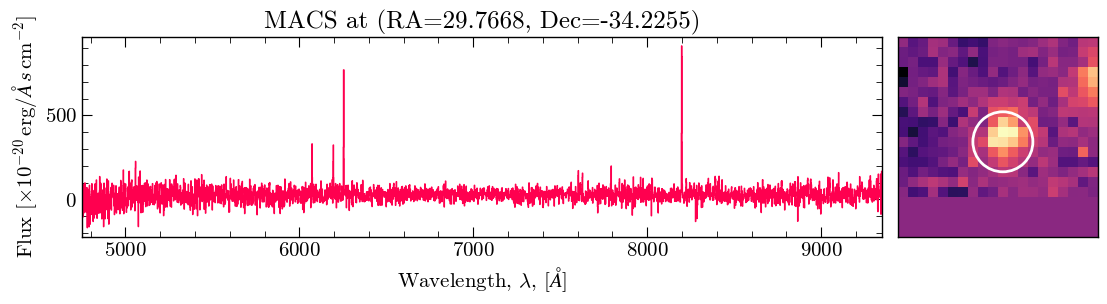

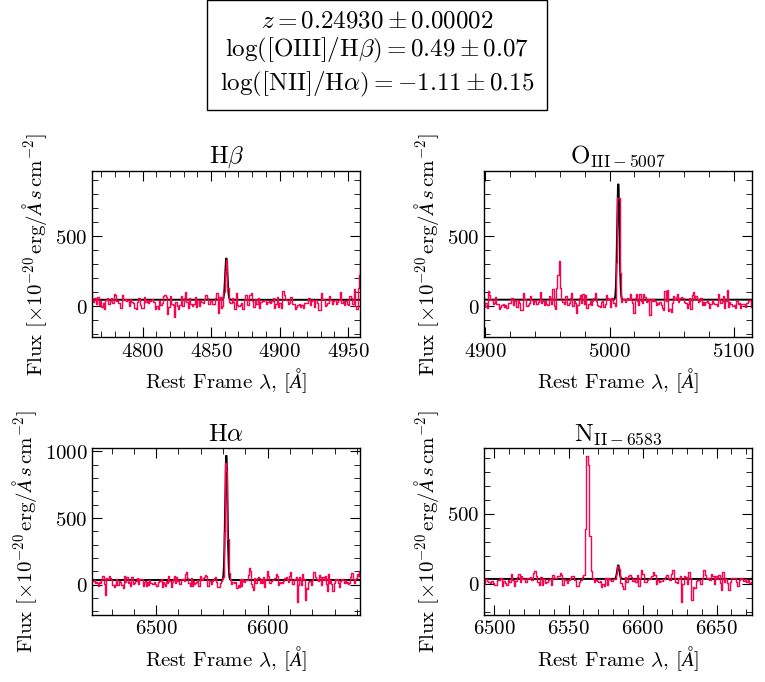

In [46]:
spec, lf1 = analyse_galaxy_spectrum(
    cube_path=CUBE_PATH,
    ra=RA_DEG,
    dec=DEC_DEG,
    radius=RADIUS_ARCSEC,
    title=TITLE,
    z_guess=Z,
    pref=ra_hms.replace('.','p')+'_'+dec_dms.replace('.','p')
)